# Stage 2 — Standard (Additive) LoRA Fine-Tuning
## Model: `meta-llama/Llama-3.2-3B-Instruct` | Dataset: CB2 (Binary Cyberbullying)

---

## Theory — Standard LoRA

**Standard LoRA — Wf = W + AB**

Standard LoRA adapts a pre-trained weight matrix W by adding a low-rank update:

> **Wf = W + AB**

where W ∈ ℝᵐˣⁿ is the frozen pre-trained weight, A ∈ ℝᵐˣʳ and B ∈ ℝʳˣⁿ are the trainable adapter matrices, and r ≪ min(m, n) is the rank. Only A and B are updated during fine-tuning; W remains completely frozen. This is the additive-only baseline — corresponds to setting L₁ = I (no multiplicative component).

---

### CB2 vs CB1 — Key Differences
| Aspect | CB1 | CB2 |
|---|---|---|
| Task | 6-class | **Binary** (cyberbullying=1 / not=0) |
| Imbalance | 1.37× (balanced) | **8.6:1** (majority = not_cyberbullying) |
| Metrics | Macro F1 + MCC | **Macro F1 + MCC + AUC-ROC** |
| Class weights | Robustness only | **Essential** — prevents majority-class collapse |
| MAX_LENGTH | 256 | **512** — conversations longer than tweets |

---

### CB2 Dataset Structure (confirmed)
- **File columns**: Date, Time, User1 ID, User2 ID, `Message`, `Label`
- **Text column**: `Message` (capital M)
- **Label column**: `Label` (capital L) — already 0/1 integers
- **Raw rows**: ~90,356 → reduces to ~9,384 after deduplication

### Model Notes — Llama-3.2-3B-Instruct
- **HF Token required** — gated model, loaded from Colab Secrets.
- **Batch size = 16** — same as CB1; 3B model fits comfortably on A100.
- **LR = 2e-4** — same as CB1.
- **Estimated runtime**: ~6–8 min per rank, ~50 min full sweep (4 ranks).

**GPU Required**: A100 (40GB).

---
## Step 1: Install Required Libraries

In [ ]:
!pip install -q -U \
    "transformers>=4.43.0" \
    "accelerate>=0.33.0" \
    "bitsandbytes>=0.43.0" \
    "peft>=0.11.1" \
    datasets scikit-learn matplotlib seaborn

print("✓ All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 152.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 57.0 MB/s eta 0:00:00
✓ All libraries installed successfully.


---
## Step 2: Import Libraries and Initial Setup

**HF Token required**: `meta-llama/Llama-3.2-3B-Instruct` is gated. Add `HF_TOKEN` to Colab Secrets before running.

In [ ]:
import os, random, collections, re, time
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef, roc_auc_score,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from peft.tuners.lora import LoraLayer
from google.colab import drive, userdata

def set_all_seeds(seed: int = 42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

def load_hf_token() -> str:
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add it via Colab Secrets (key icon in sidebar).")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()

drive.mount('/content/drive')
print("✓ Google Drive mounted.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

In [ ]:
MODEL_NAME     = "meta-llama/Llama-3.2-3B-Instruct"
NUM_LABELS     = 2
MAX_LENGTH     = 512        # conversations longer than tweets
POSITIVE_LABEL = 1          # cyberbullying = minority positive class

LORA_RANK      = 16
LORA_ALPHA     = 16
LORA_DROPOUT   = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP     = [4, 8, 16, 32]

NUM_EPOCHS          = 1
LEARNING_RATE       = 2e-4
TRAIN_BATCH_SIZE    = 16
EVAL_BATCH_SIZE     = 32
WEIGHT_DECAY        = 0.01
EVAL_STEPS          = 100   # more frequent — fewer steps per epoch on CB2
LOGGING_STEPS       = 50
OUTPUT_DIR          = "/content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B"

CB2_PATH             = "/content/drive/MyDrive/Datasets/cb2.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# CB2 confirmed label mapping — already 0/1 integers in dataset
LABEL_MAPPING = {0: 'not_cyberbullying', 1: 'cyberbullying'}
ID2LABEL      = LABEL_MAPPING
TARGET_NAMES  = ['not_cyberbullying', 'cyberbullying']

print("✓ Configuration loaded.")
print(f"  Model      : {MODEL_NAME}")
print(f"  Task       : Binary CB2 — 8.6:1 imbalanced")
print(f"  LoRA rank  : {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  Batch size : {TRAIN_BATCH_SIZE} train / {EVAL_BATCH_SIZE} eval")
print(f"  LR         : {LEARNING_RATE}")
print(f"  MAX_LENGTH : {MAX_LENGTH}  (conversations)")
print(f"  Metrics    : Macro F1 (primary) | MCC + AUC-ROC (secondary)")

✓ Configuration loaded.
  Model      : meta-llama/Llama-3.2-3B-Instruct
  Task       : Binary CB2 — 8.6:1 imbalanced
  LoRA rank  : 16  |  alpha: 16  |  scaling: 1.0
  Epochs     : 1
  Batch size : 16 train / 32 eval
  LR         : 0.0002
  MAX_LENGTH : 512  (conversations)
  Metrics    : Macro F1 (primary) | MCC + AUC-ROC (secondary)


---
## Step 4: Text Preprocessing

In [ ]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    if not isinstance(text, str): return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags: text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis: text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3: return ""
    return text

print("✓ Preprocessing function defined.")

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB2 Dataset

**CB2 confirmed column structure**:
- Text  → `Message` column (capital M)
- Label → `Label` column (capital L) — values already 0/1 integers
- Raw file has ~90,356 rows; after deduplication reduces to ~9,384

**Why the large drop?** CB2 is a conversation dataset — many messages repeat across
conversations. Deduplication at the message level removes ~80,000 duplicates.

In [ ]:
print("═" * 60)
print("CB2 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB2_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")
print(f"    Columns: {df.columns.tolist()}")

# ── Fixed column assignment (CB2 confirmed structure) ─────────────────────
# Text column  : 'Message' (capital M)
# Label column : 'Label'   (capital L) — already 0/1 integers
TEXT_COL  = 'Message'
LABEL_COL = 'Label'
print(f"[2] Text column: '{TEXT_COL}'  |  Label column: '{LABEL_COL}'")

df = df.rename(columns={TEXT_COL: 'text', LABEL_COL: 'label'})
df = df[['text', 'label']].copy()

# ── Corrupt row removal ───────────────────────────────────────────────────
corrupt_mask = df['text'].astype(str).str.strip().isin(
    ['#NAME?', '#REF!', '#VALUE!', '#N/A', 'nan', ''])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {corrupt_mask.sum()} corrupt rows → {len(df):,} remaining")

# ── Label validation — already 0/1 integers ───────────────────────────────
unique_labels = sorted(df['label'].unique())
print(f"[4] Unique label values: {unique_labels}")
assert set(unique_labels).issubset({0, 1}), f"Unexpected labels: {unique_labels}"
df['label'] = df['label'].astype(int)
print(f"    ✓ Labels confirmed: 0=not_cyberbullying | 1=cyberbullying")

# ── Text preprocessing ────────────────────────────────────────────────────
df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[5] After preprocessing: {len(df):,} remaining")

# ── Exact duplicate removal ───────────────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")

# ── Short text removal ────────────────────────────────────────────────────
before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before - len(df):,} short texts → {len(df):,} remaining")

# ── Imbalance report ──────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("FINAL CB2 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts().sort_index()
for lbl, count in counts.items():
    name = ID2LABEL.get(lbl, str(lbl))
    print(f"  {name:<25} (label={lbl})  {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25}         {len(df):>6}")
imbalance = counts.max() / counts.min()
print(f"\n  Imbalance ratio : {imbalance:.2f}:1  ← class weights ESSENTIAL")
print("  Primary metric  : Macro F1  |  Secondary: MCC + AUC-ROC")

════════════════════════════════════════════════════════════
CB2 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 90,356 samples
    Columns: ['Date', 'Time', 'User1 ID', 'User2 ID', 'Message', 'Label']
[2] Text column: 'Message'  |  Label column: 'Label'
[3] Removed 0 corrupt rows → 90,356 remaining
[4] Unique label values: [np.int64(0), np.int64(1)]
    ✓ Labels confirmed: 0=not_cyberbullying | 1=cyberbullying
[5] After preprocessing: 89,632 remaining
[6] Removed 107 exact duplicates → 89,525 remaining
[7] Removed 0 short texts → 89,525 remaining

════════════════════════════════════════════════════════════
FINAL CB2 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  not_cyberbullying         (label=0)   59002  (65.9%)
  cyberbullying             (label=1)   30523  (34.1%)
  TOTAL                              89525

  Imbalance ratio : 1.93:1  ← class weights ESSENTIAL
  Primary metric  : M

---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

In [ ]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end         = min(start + 500, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    leaked_mask = batch_sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df        = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df   = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

overlap = set(train_val_df['text'].tolist()).intersection(set(test_df['text'].tolist()))
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed — zero train/test overlap.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE,
    stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\n[3] Validation carved → Train: {len(train_df):,} | Val: {len(val_df):,}")

print("\n" + "═" * 60)
print("FINAL SPLIT STATISTICS")
print("═" * 60)
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct      = len(split_df) / len(df) * 100
    pos_rate = split_df['label'].mean() * 100
    print(f"\n{name} ({len(split_df):,} samples, {pct:.1f}% | {pos_rate:.1f}% cyberbullying):")
    for lbl, count in split_df['label'].value_counts().sort_index().items():
        print(f"  {ID2LABEL[lbl]:<25} {count:>5}  ({count/len(split_df)*100:.1f}%)")
print(f"\n  ✓ Protocol check : test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")
print(f"  ✓ Approx steps   : {len(train_df) // TRAIN_BATCH_SIZE} per epoch at batch={TRAIN_BATCH_SIZE}")

════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 67,143 | Test: 22,382

[2] Near-duplicate check (threshold: 0.9)...
    Found 2036 near-duplicate test samples
    Moved to train → Train+Val: 69,179 | Test: 20,346

    ✓ Data leakage assertion passed — zero train/test overlap.

[3] Validation carved → Train: 62,261 | Val: 6,918

════════════════════════════════════════════════════════════
FINAL SPLIT STATISTICS
════════════════════════════════════════════════════════════

Train (62,261 samples, 69.5% | 34.8% cyberbullying):
  not_cyberbullying         40571  (65.2%)
  cyberbullying             21690  (34.8%)

Validation (6,918 samples, 7.7% | 34.8% cyberbullying):
  not_cyberbullying          4508  (65.2%)
  cyberbullying              2410  (34.8%)

Test (20,346 samples, 22.7% | 31.6% cyberbullying):
  not_cyberbullying         1392

---
## Step 7: Class Weights — Essential for 8.6:1 Imbalance

In [ ]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    """Inverse-frequency class weights. Essential for CB2 8.6:1 imbalance."""
    class_counts = df[label_col].value_counts().sort_index()
    N = class_counts.sum(); C = len(class_counts)
    weights = N / (C * class_counts.values)
    weights = weights / weights.sum()
    return weights.tolist()

train_class_weights = get_class_weights(train_df)
print("Class weights (inverse frequency, normalised):")
for lbl, w in enumerate(train_class_weights):
    print(f"  {ID2LABEL[lbl]:<25} (label={lbl})  weight = {w:.4f}")
ratio = train_class_weights[1] / train_class_weights[0]
print(f"\n  Cyberbullying weight / not_cb weight = {ratio:.2f}×")
print(f"  → Missing a cyberbullying sample costs {ratio:.1f}× more in the loss")
print("\n✓ Class weights ready — passed to CustomTrainer.")

Class weights (inverse frequency, normalised):
  not_cyberbullying         (label=0)  weight = 0.3484
  cyberbullying             (label=1)  weight = 0.6516

  Cyberbullying weight / not_cb weight = 1.87×
  → Missing a cyberbullying sample costs 1.9× more in the loss

✓ Class weights ready — passed to CustomTrainer.


---
## Step 8: Effective Rank Computation — CORRECTED (4-bit QLoRA Compatible)

In [ ]:
def calculate_effective_rank(model: nn.Module,
                              threshold_ratio: float = 1e-3) -> Dict[str, float]:
    try:
        import bitsandbytes.functional as bnb_F; BNB_AVAILABLE = True
    except ImportError:
        BNB_AVAILABLE = False

    full_ranks = []; delta_ranks = []; per_layer = []; skipped = 0
    for name, module in model.named_modules():
        if not isinstance(module, LoraLayer): continue
        try:
            A = module.lora_A.default.weight.data
            B = module.lora_B.default.weight.data
            scaling = module.scaling
            if isinstance(scaling, dict): scaling = scaling.get('default', 1.0)
            delta_W = (B @ A * scaling).float()
            S_delta = torch.linalg.svdvals(delta_W)
            r_delta = int((S_delta > threshold_ratio * S_delta[0]).sum()) if S_delta[0] > 0 else 0
            delta_ranks.append(r_delta)
            base_layer = module.base_layer
            if not hasattr(base_layer, 'weight'): skipped += 1; continue
            weight_obj = base_layer.weight
            if hasattr(weight_obj, 'quant_state') and BNB_AVAILABLE:
                try: W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                except Exception: skipped += 1; continue
            else:
                W = weight_obj.data.float()
            if W.shape != delta_W.shape:
                if W.T.shape == delta_W.shape: W = W.T.contiguous()
                else: skipped += 1; continue
            Wf = W + delta_W
            S_Wf = torch.linalg.svdvals(Wf)
            r_full = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_full)
            per_layer.append({'layer': name, 'rank_Wf': r_full, 'rank_deltaW': r_delta})
        except Exception: skipped += 1; continue
    if skipped > 0: print(f"  ℹ {skipped} LoRA layers skipped")
    return {
        "avg_effective_rank_Wf":     float(np.mean(full_ranks))  if full_ranks  else 0.0,
        "avg_effective_rank_deltaW": float(np.mean(delta_ranks)) if delta_ranks else 0.0,
        "lora_layer_count":          len(full_ranks),
        "per_layer_ranks":           per_layer,
    }

print("✓ calculate_effective_rank() — 4-bit QLoRA compatible.")

✓ calculate_effective_rank() — 4-bit QLoRA compatible.


---
## Step 9: Evaluation Metrics — CB2 (Binary + AUC-ROC)

Three metrics:
- **Macro F1** — primary, penalises ignoring minority class
- **MCC** — secondary, accounts for all four confusion matrix quadrants
- **AUC-ROC** — secondary, uses softmax probabilities of the positive class (cyberbullying=1)

In [ ]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    """Called by Trainer at eval_steps — Macro F1 + MCC (no AUC, needs probs)."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true: List[int], y_pred: List[int],
                     y_prob: List[float], dataset_name: str) -> Dict[str, float]:
    """Full CB2 evaluation: Macro F1 + MCC + AUC-ROC. y_prob = P(cyberbullying=1)."""
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_cb        = f1_score(y_true, y_pred, pos_label=1, average='binary', zero_division=0)
    f1_not_cb    = f1_score(y_true, y_pred, pos_label=0, average='binary', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)
    try:
        auc_roc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc_roc = float('nan')
        print("  ⚠ AUC-ROC could not be computed.")

    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"  AUC-ROC           : {auc_roc:.4f}  ← SECONDARY METRIC")
    print(f"  F1 cyberbullying  : {f1_cb:.4f}  (minority class — label=1)")
    print(f"  F1 not_cb         : {f1_not_cb:.4f}  (majority class — label=0)")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES,
                                 zero_division=0, digits=4))

    cm      = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised — Recall)\n{dataset_name}')
    axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'accuracy': accuracy, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
        'balanced_accuracy': bal_accuracy, 'mcc': mcc, 'auc_roc': auc_roc,
        'f1_cyberbullying': f1_cb, 'f1_not_cb': f1_not_cb,
    }


def make_predictions(model, df_test, tokenizer, batch_size=32):
    """CB2 inference — returns predictions + prob_cyberbullying for AUC-ROC."""
    model.eval()
    sentences  = df_test['text'].tolist(); all_logits = []
    dev        = next(model.parameters()).device
    with torch.no_grad():
        for start in range(0, len(sentences), batch_size):
            batch   = sentences[start:start + batch_size]
            inputs  = tokenizer(batch, return_tensors="pt",
                                padding=True, truncation=True, max_length=MAX_LENGTH)
            inputs  = {k: v.to(dev) for k, v in inputs.items()}
            outputs = model(**inputs)
            all_logits.append(outputs.logits.cpu())
    all_logits = torch.cat(all_logits, dim=0)
    probs      = torch.softmax(all_logits, dim=1)
    df_test    = df_test.copy()
    df_test['predictions']        = all_logits.argmax(dim=1).numpy()
    df_test['prob_cyberbullying'] = probs[:, POSITIVE_LABEL].numpy()
    return df_test

print("✓ CB2 metric functions defined.")
print("  → compute_metrics    : Macro F1 + MCC (Trainer)")
print("  → evaluate_dataset   : Macro F1 + MCC + AUC-ROC + dual confusion matrix")
print("  → make_predictions   : predictions + prob_cyberbullying for AUC-ROC")

✓ CB2 metric functions defined.
  → compute_metrics    : Macro F1 + MCC (Trainer)
  → evaluate_dataset   : Macro F1 + MCC + AUC-ROC + dual confusion matrix
  → make_predictions   : predictions + prob_cyberbullying for AUC-ROC


---
## Step 10: Training Stability System

In [ ]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []; self.val_metrics = collections.defaultdict(list); self.val_steps = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs: self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            self.val_metrics[key.replace('eval_', '')].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr)/np.mean(arr)) if np.mean(arr)>0 else 0.0
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max()-arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])
        report['stability_score'] = round(
            (report.get('loss_cv_overall', 0.0) * 0.5) +
            (report.get('val_f1_std', 0.0) * 0.5), 6)
        return report

    def plot_stability_curves(self, stage_label='Stage 2', save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        if self.train_losses:
            steps = [s for (s,_) in self.train_losses]; losses = [l for (_,l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy', linewidth=2.2,
                         label=f'Rolling mean (w={window})')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)
            ax1.set_xlabel('Global Step'); ax1.set_ylabel('Cross-Entropy Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                f1_mean = float(np.mean(f1_vals)); f1_std = float(np.std(f1_vals))
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen', linewidth=2,
                         markersize=5, label='Macro F1')
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':', linewidth=1.2, alpha=0.6)
                ax2.fill_between(self.val_steps, [f1_mean-f1_std]*len(self.val_steps),
                                  [f1_mean+f1_std]*len(self.val_steps),
                                  color='forestgreen', alpha=0.10, label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen', fontsize=10)
                ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2_r is not None and 'mcc' in self.val_metrics:
                ax2_r.plot(self.val_steps, self.val_metrics['mcc'], 's--', color='darkorange',
                           linewidth=2, markersize=5, label='MCC')
                ax2_r.set_ylabel('MCC', color='darkorange', fontsize=10)
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
                lines1, lbl1 = ax2.get_legend_handles_labels()
                lines2, lbl2 = ax2_r.get_legend_handles_labels()
                ax2.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='lower right')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)
            ax2.set_xlabel('Global Step'); ax2.grid(True, alpha=0.3)
        plt.suptitle(f'Training Stability — {stage_label}', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'  ✓ Stability plot saved → {save_path}')
        plt.show()


class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
                              if class_weights is not None else None)

    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels  = inputs.pop('labels').long(); outputs = model(**inputs)
        loss    = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss

print("✓ StabilityCallback + CustomTrainer (class-weighted loss) defined.")

✓ StabilityCallback + CustomTrainer (class-weighted loss) defined.


---
## Step 11: Standard LoRA Training Function — CB2

In [ ]:
def run_standard_lora(
    train_df, val_df, test_df, lora_rank, run_label=''
) -> Dict:
    """Train and evaluate Standard LoRA on CB2 (binary). Formula: Wf = W + AB"""
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label      = run_label or f'StandardLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 2 CB2 — STANDARD LoRA  |  {label}')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Rank r  : {lora_rank}  |  Alpha: {lora_alpha}  |  Scaling: {lora_alpha/lora_rank:.1f}')
    print(f'  Formula : Wf = W + AB  |  Task: Binary CB2')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # ── 1. Tokenizer ──────────────────────────────────────────────────────────
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME, token=HF_TOKEN, add_prefix_space=True)
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab size: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'], padding='max_length',
                         truncation=True, max_length=MAX_LENGTH)

    # ── 2. Datasets ───────────────────────────────────────────────────────────
    print('[2] Preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()

    hf_train = Dataset.from_pandas(train_m[['text','label']].reset_index(drop=True)
               ).map(tokenise, batched=True, remove_columns=['text'])
    hf_val   = Dataset.from_pandas(val_m[['text','label']].reset_index(drop=True)
               ).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    # ── 3. Quantisation ───────────────────────────────────────────────────────
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)

    # ── 4. LoRA config ────────────────────────────────────────────────────────
    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha,
        target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT, bias='none', task_type='SEQ_CLS')

    # ── 5. Load model ─────────────────────────────────────────────────────────
    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        num_labels=NUM_LABELS,
        dtype=torch.bfloat16,
        device_map='auto',
        token=HF_TOKEN,
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache    = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    trainable, total = model.get_nb_trainable_parameters()
    print(f'   Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)')

    # ── 6. Training arguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=run_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='steps', eval_steps=EVAL_STEPS,
        logging_strategy='steps', logging_steps=LOGGING_STEPS,
        save_strategy='no', load_best_model_at_end=False,
        warmup_ratio=0.05, lr_scheduler_type='cosine',
        fp16=False, bf16=True,
        report_to='none', dataloader_pin_memory=False,
    )

    # ── 7. Trainer ────────────────────────────────────────────────────────────
    stability_cb = StabilityCallback()
    cw           = get_class_weights(train_m)
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics,
        class_weights=cw,
        callbacks=[stability_cb])
    print(f'   Class weights: not_cb={cw[0]:.4f}  |  cyberbullying={cw[1]:.4f}')

    # ── 8. Train ──────────────────────────────────────────────────────────────
    print(f'[4] Training — {NUM_EPOCHS} epoch...')
    trainer.train()
    train_runtime = trainer.state.log_history[-1].get('train_runtime', 0)
    print(f"Training time: {train_runtime:.0f}s  ({train_runtime/3600:.2f} hrs)")

    # ── 9. Effective rank ─────────────────────────────────────────────────────
    print('\n[5] Computing effective rank...')
    rank_metrics = calculate_effective_rank(model)
    print(f'   avg_effective_rank(Wf) = {rank_metrics["avg_effective_rank_Wf"]:.2f}')
    print(f'   avg_effective_rank(ΔW) = {rank_metrics["avg_effective_rank_deltaW"]:.2f}  (≤ r={lora_rank})')

    # ── 10. Stability ─────────────────────────────────────────────────────────
    print('\n[6] Generating stability report...')
    stability_report = stability_cb.get_stability_report()
    for k in ['loss_cv_overall','loss_std_overall','val_f1_std','stability_score']:
        print(f'   {k:<20}: {stability_report.get(k, "N/A")}')
    stability_cb.plot_stability_curves(
        stage_label=f'Stage 2 CB2 — Standard LoRA  (Wf=W+AB, r={lora_rank})',
        save_path=os.path.join(run_dir, 'stability_curves.png'))

    # ── 11. Inference + AUC-ROC ───────────────────────────────────────────────
    print('[7] Running inference on held-out test set (25%)...')
    test_with_preds = make_predictions(model, test_m, tokenizer)
    final_metrics = evaluate_dataset(
        y_true=test_with_preds['label'].tolist(),
        y_pred=test_with_preds['predictions'].tolist(),
        y_prob=test_with_preds['prob_cyberbullying'].tolist(),
        dataset_name=f'CB2 Test — {label}')

    # ── 12. Save ──────────────────────────────────────────────────────────────
    results = {
        'run_label': label, 'lora_rank': lora_rank, 'lora_alpha': lora_alpha,
        'trainable_params': trainable, **final_metrics,
        'avg_eff_rank_Wf':  rank_metrics['avg_effective_rank_Wf'],
        'avg_eff_rank_dW':  rank_metrics['avg_effective_rank_deltaW'],
        'stability_score':  stability_report.get('stability_score', None),
        'train_runtime_s':  train_runtime,
        'stability_report': stability_report,
        'stability_cb':     stability_cb,
    }
    scalars_path = os.path.join(run_dir, f'results_{label}.csv')
    pd.DataFrame([{k: v for k, v in results.items()
                   if not isinstance(v, (dict, StabilityCallback))}
                 ]).to_csv(scalars_path, index=False)
    print(f'\n✓ Results saved → {scalars_path}')
    del model, trainer; torch.cuda.empty_cache()
    return results

print('✓ run_standard_lora() — CB2 version defined.')
print('  → Class weights mandatory (8.6:1 imbalance)')
print('  → AUC-ROC from softmax probabilities')
print('  → Training time printed + saved to CSV')

✓ run_standard_lora() — CB2 version defined.
  → Class weights mandatory (8.6:1 imbalance)
  → AUC-ROC from softmax probabilities
  → Training time printed + saved to CSV


---
## Step 12: Execute — Default Run (r = 16)

**CB2 targets to beat** (Stage 1):
- DeBERTa ZS encoder: Macro F1 = 0.5957 ← true ceiling
- Phi-4 FS decoder:   Macro F1 = 0.5170  |  AUC-ROC = 0.664
- DeBERTa frozen FS:  Macro F1 = 0.0941  ← worst (MCC negative)

✓ All random seeds fixed to 42.

  STAGE 2 CB2 — STANDARD LoRA  |  StandardLoRA_r16
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W + AB  |  Task: Binary CB2

[1] Loading tokenizer...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.537217,0.401695,0.825672,0.817216,0.648387
200,0.397796,0.339166,0.864267,0.851215,0.702531
300,0.347802,0.287445,0.870194,0.862324,0.732607
400,0.338949,0.304975,0.848222,0.842631,0.709332
500,0.283373,0.298190,0.868748,0.861389,0.732956
600,0.390809,0.289600,0.877855,0.870287,0.748023
700,0.367429,0.358709,0.876843,0.858581,0.724169
800,0.328140,0.353575,0.880890,0.864031,0.733354
900,0.276314,0.270840,0.884071,0.876048,0.756848
1000,0.289734,0.279387,0.876409,0.868337,0.742745


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.537217,0.401695,0.825672,0.817216,0.648387
200,0.397796,0.339166,0.864267,0.851215,0.702531
300,0.347802,0.287445,0.870194,0.862324,0.732607
400,0.338949,0.304975,0.848222,0.842631,0.709332
500,0.283373,0.298190,0.868748,0.861389,0.732956
600,0.390809,0.289600,0.877855,0.870287,0.748023
700,0.367429,0.358709,0.876843,0.858581,0.724169
800,0.328140,0.353575,0.880890,0.864031,0.733354
900,0.276314,0.270840,0.884071,0.876048,0.756848
1000,0.289734,0.279387,0.876409,0.868337,0.742745


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training time: 12874s  (3.58 hrs)

[5] Computing effective rank...
   avg_effective_rank(Wf) = 2030.70
   avg_effective_rank(ΔW) = 16.00  (≤ r=16)

[6] Generating stability report...
   loss_cv_overall     : 0.30500112549228653
   loss_std_overall    : 0.08883687355407135
   val_f1_std          : 0.016757759715833567
   stability_score     : 0.160879
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r16/stability_curves.png


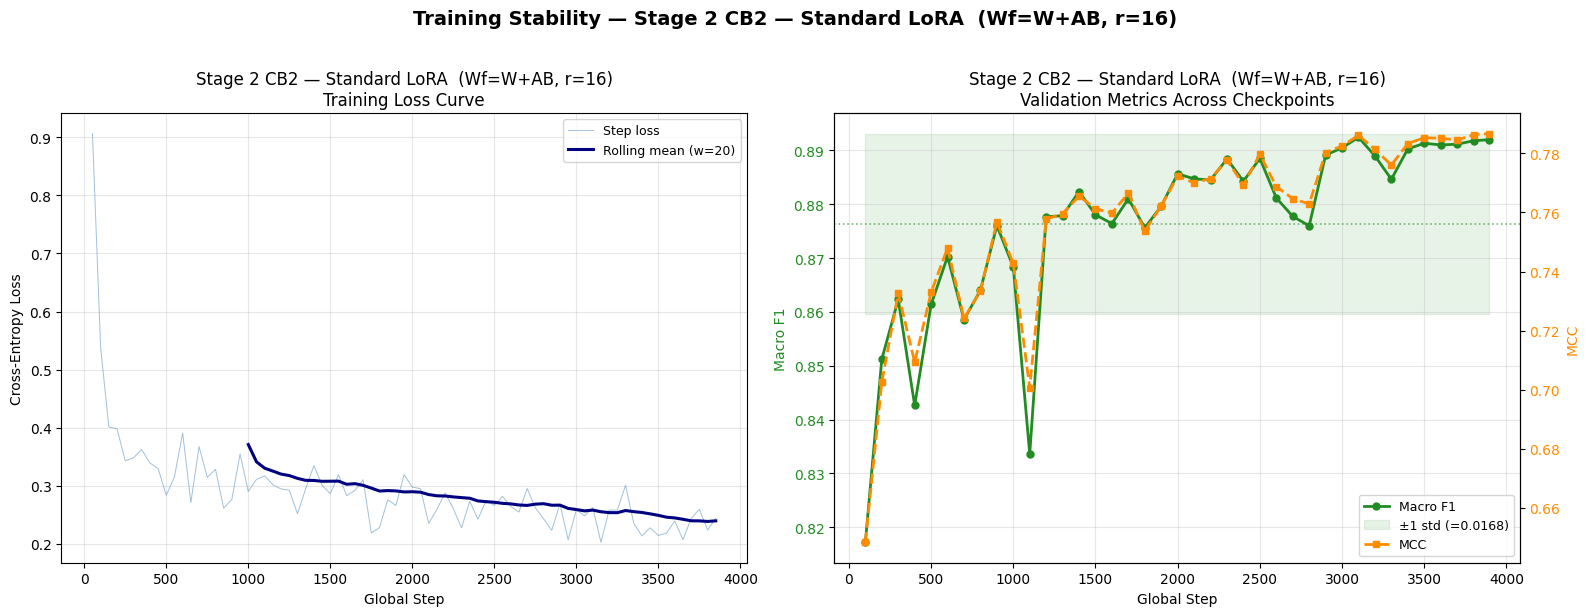

[7] Running inference on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB2 Test — StandardLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9008
  Macro F1          : 0.8885  ← PRIMARY METRIC
  Weighted F1       : 0.9022
  Balanced Accuracy : 0.9009
  MCC               : 0.7800  ← SECONDARY METRIC
  AUC-ROC           : 0.9650  ← SECONDARY METRIC
  F1 cyberbullying  : 0.8515  (minority class — label=1)
  F1 not_cb         : 0.9255  (majority class — label=0)

  Classification Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9517    0.9007    0.9255     13923
    cyberbullying     0.8072    0.9010    0.8515      6423

         accuracy                         0.9008     20346
        macro avg     0.8795    0.9009    0.8885     20346
     weighted avg     0.9061    0.9008    0.9022     20346



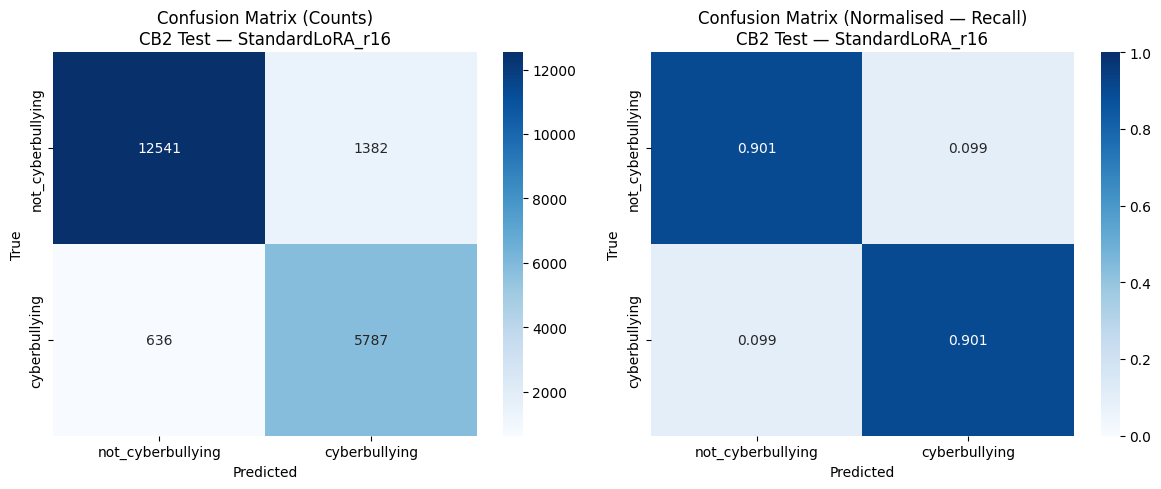


✓ Results saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r16/results_StandardLoRA_r16.csv

══════════════════════════════════════════════════════════════
  STAGE 2 CB2 RESULTS — Standard LoRA (r=16)
  Formula: Wf = W + AB  |  Model: meta-llama/Llama-3.2-3B-Instruct
══════════════════════════════════════════════════════════════
  Macro F1          : 0.8885   ← PRIMARY METRIC
  MCC               : 0.7800   ← SECONDARY
  AUC-ROC           : 0.9650   ← SECONDARY
  F1 cyberbullying  : 0.8515   (minority class)
  Accuracy          : 0.9008
  Trainable params  : 9,181,184
  Eff. rank Wf      : 2030.70
  Training time     : 12874s  (3.58 hrs)
══════════════════════════════════════════════════════════════

  CB2 Stage 1 targets:
  DeBERTa ZS : F1=0.5957  MCC=0.2153            ← CEILING
  Phi-4 FS   : F1=0.5170  MCC=0.2030  AUC=0.664


In [ ]:
results_r16 = run_standard_lora(
    train_df=train_df, val_df=val_df, test_df=test_df,
    lora_rank=16, run_label='StandardLoRA_r16')

print('\n' + '═'*62)
print('  STAGE 2 CB2 RESULTS — Standard LoRA (r=16)')
print('  Formula: Wf = W + AB  |  Model: meta-llama/Llama-3.2-3B-Instruct')
print('═'*62)
print(f'  Macro F1          : {results_r16["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC               : {results_r16["mcc"]:.4f}   ← SECONDARY')
print(f'  AUC-ROC           : {results_r16["auc_roc"]:.4f}   ← SECONDARY')
print(f'  F1 cyberbullying  : {results_r16["f1_cyberbullying"]:.4f}   (minority class)')
print(f'  Accuracy          : {results_r16["accuracy"]:.4f}')
print(f'  Trainable params  : {results_r16["trainable_params"]:,}')
print(f'  Eff. rank Wf      : {results_r16["avg_eff_rank_Wf"]:.2f}')
runtime = results_r16.get("train_runtime_s", 0)
print(f'  Training time     : {runtime:.0f}s  ({runtime/3600:.2f} hrs)')
print('═'*62)
print()
print('  CB2 Stage 1 targets:')
print('  DeBERTa ZS : F1=0.5957  MCC=0.2153            ← CEILING')
print('  Phi-4 FS   : F1=0.5170  MCC=0.2030  AUC=0.664')

---
## Step 13: Rank Sweep Ablation — r ∈ {4, 8, 16, 32}

Total compute time is tracked and printed at the end of the sweep.
Each completed rank saves its CSV to Drive immediately.


───────────────────────────────────────────────────────
  Rank sweep: r = 4
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 CB2 — STANDARD LoRA  |  StandardLoRA_r4
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 4  |  Alpha: 4  |  Scaling: 1.0
  Formula : Wf = W + AB  |  Task: Binary CB2

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Preparing datasets...


Map:   0%|          | 0/62261 [00:00<?, ? examples/s]

Map:   0%|          | 0/6918 [00:00<?, ? examples/s]

   Train: 62,261 | Val: 6,918 | Test: 20,346
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

   Trainable: 2,299,904 / 3,215,055,872  (0.072%)
   Class weights: not_cb=0.3484  |  cyberbullying=0.6516
[4] Training — 1 epoch...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.595197,0.474393,0.765250,0.758579,0.547659
200,0.380121,0.322254,0.855739,0.845924,0.696803
300,0.347265,0.297693,0.861665,0.854164,0.719410
400,0.364361,0.283631,0.873229,0.864594,0.734233
500,0.270041,0.333220,0.879445,0.865744,0.732042
600,0.364540,0.287689,0.869326,0.862551,0.737699
700,0.380933,0.494462,0.857040,0.828381,0.682905
800,0.313228,0.357900,0.879300,0.862136,0.729714
900,0.279309,0.277518,0.881613,0.873088,0.750048
1000,0.284936,0.273723,0.880457,0.872764,0.752010


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training time: 12946s  (3.60 hrs)

[5] Computing effective rank...
   avg_effective_rank(Wf) = 2030.68
   avg_effective_rank(ΔW) = 4.00  (≤ r=4)

[6] Generating stability report...
   loss_cv_overall     : 0.31697401328070723
   loss_std_overall    : 0.09269453231343341
   val_f1_std          : 0.022575267303238788
   stability_score     : 0.169775
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r4/stability_curves.png


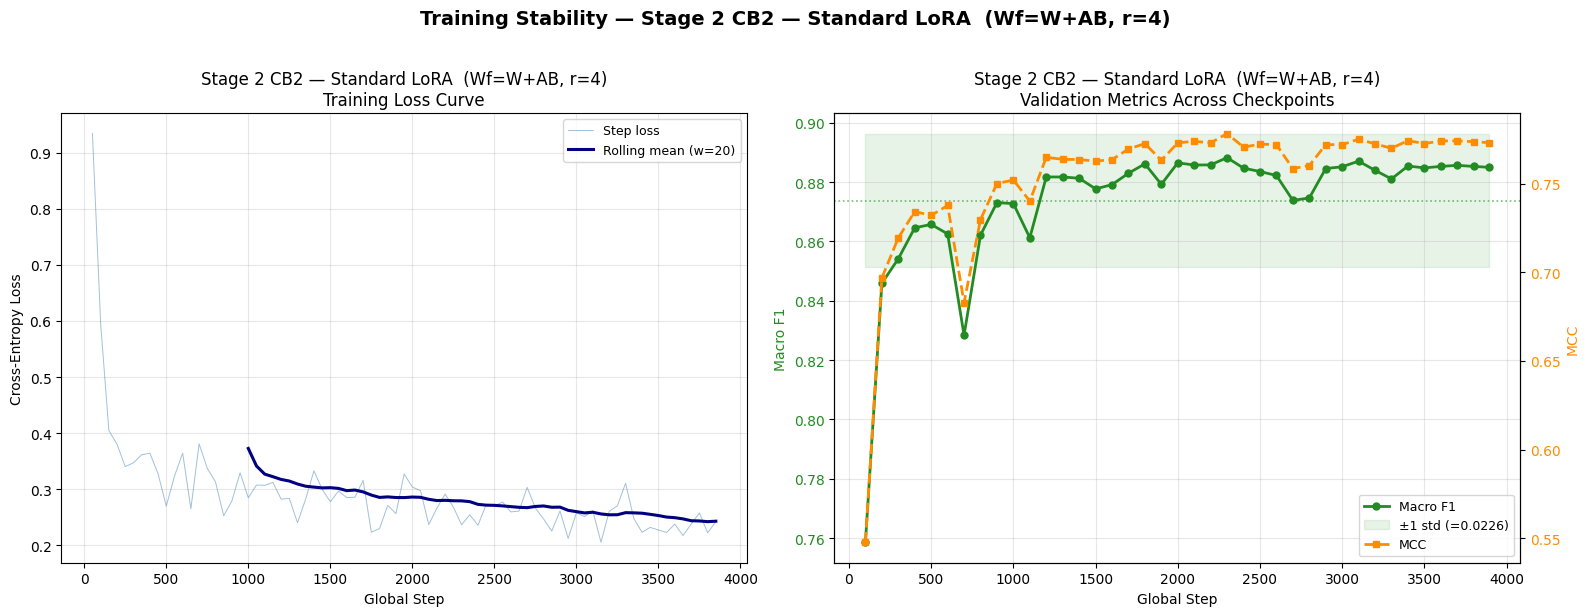

[7] Running inference on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB2 Test — StandardLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8959
  Macro F1          : 0.8835  ← PRIMARY METRIC
  Weighted F1       : 0.8975
  Balanced Accuracy : 0.8977
  MCC               : 0.7709  ← SECONDARY METRIC
  AUC-ROC           : 0.9627  ← SECONDARY METRIC
  F1 cyberbullying  : 0.8455  (minority class — label=1)
  F1 not_cb         : 0.9215  (majority class — label=0)

  Classification Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9521    0.8927    0.9215     13923
    cyberbullying     0.7951    0.9027    0.8455      6423

         accuracy                         0.8959     20346
        macro avg     0.8736    0.8977    0.8835     20346
     weighted avg     0.9026    0.8959    0.8975     20346



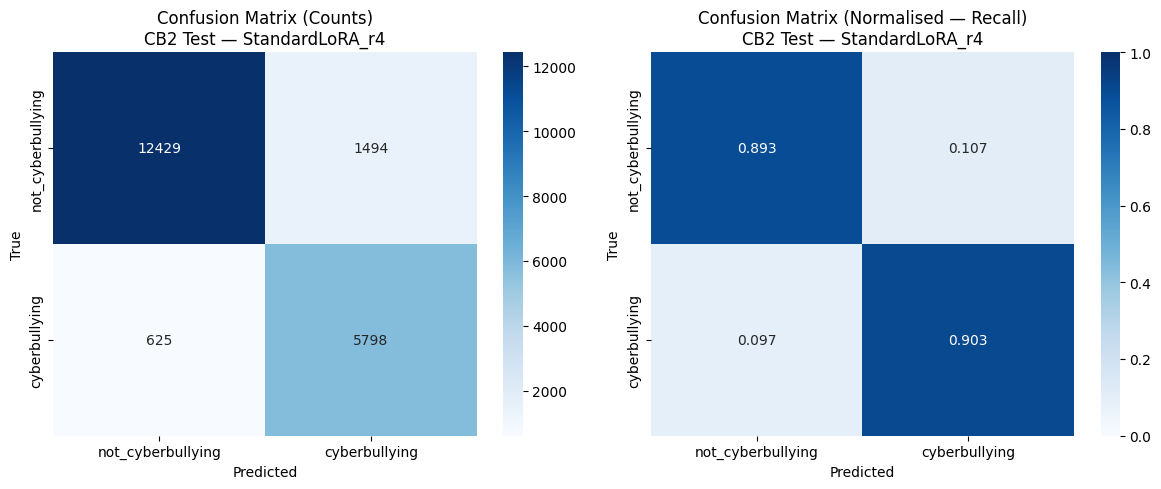


✓ Results saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r4/results_StandardLoRA_r4.csv

───────────────────────────────────────────────────────
  Rank sweep: r = 8
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 CB2 — STANDARD LoRA  |  StandardLoRA_r8
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 8  |  Alpha: 8  |  Scaling: 1.0
  Formula : Wf = W + AB  |  Task: Binary CB2

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Preparing datasets...


Map:   0%|          | 0/62261 [00:00<?, ? examples/s]

Map:   0%|          | 0/6918 [00:00<?, ? examples/s]

   Train: 62,261 | Val: 6,918 | Test: 20,346
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

   Trainable: 4,593,664 / 3,217,349,632  (0.143%)
   Class weights: not_cb=0.3484  |  cyberbullying=0.6516
[4] Training — 1 epoch...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.568805,0.437112,0.795027,0.788087,0.601576
200,0.388474,0.327536,0.857473,0.847222,0.698217
300,0.335363,0.296149,0.866146,0.858661,0.727544
400,0.355455,0.303542,0.880601,0.868355,0.736716
500,0.281707,0.339228,0.851547,0.845679,0.712926
600,0.365376,0.304099,0.858630,0.852484,0.723303
700,0.375908,0.353671,0.875831,0.857707,0.721785
800,0.315645,0.368907,0.876409,0.857862,0.723225
900,0.285768,0.283269,0.875831,0.867821,0.742021
1000,0.284611,0.275471,0.880890,0.873004,0.751777


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training time: 12876s  (3.58 hrs)

[5] Computing effective rank...
   avg_effective_rank(Wf) = 2030.71
   avg_effective_rank(ΔW) = 8.00  (≤ r=8)

[6] Generating stability report...
   loss_cv_overall     : 0.3123116446720648
   loss_std_overall    : 0.0908190220479831
   val_f1_std          : 0.01907277522782432
   stability_score     : 0.165692
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r8/stability_curves.png


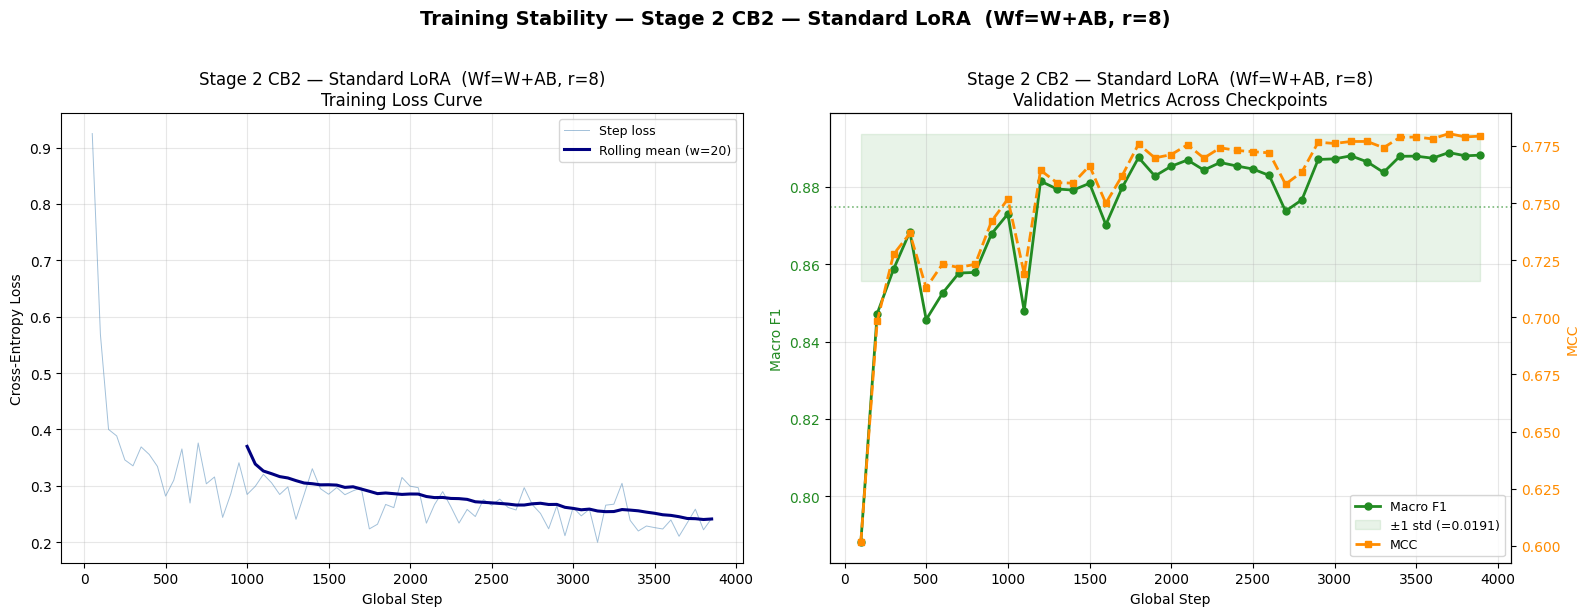

[7] Running inference on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB2 Test — StandardLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8975
  Macro F1          : 0.8852  ← PRIMARY METRIC
  Weighted F1       : 0.8990
  Balanced Accuracy : 0.8989
  MCC               : 0.7740  ← SECONDARY METRIC
  AUC-ROC           : 0.9640  ← SECONDARY METRIC
  F1 cyberbullying  : 0.8475  (minority class — label=1)
  F1 not_cb         : 0.9228  (majority class — label=0)

  Classification Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9522    0.8951    0.9228     13923
    cyberbullying     0.7987    0.9027    0.8475      6423

         accuracy                         0.8975     20346
        macro avg     0.8755    0.8989    0.8852     20346
     weighted avg     0.9038    0.8975    0.8990     20346



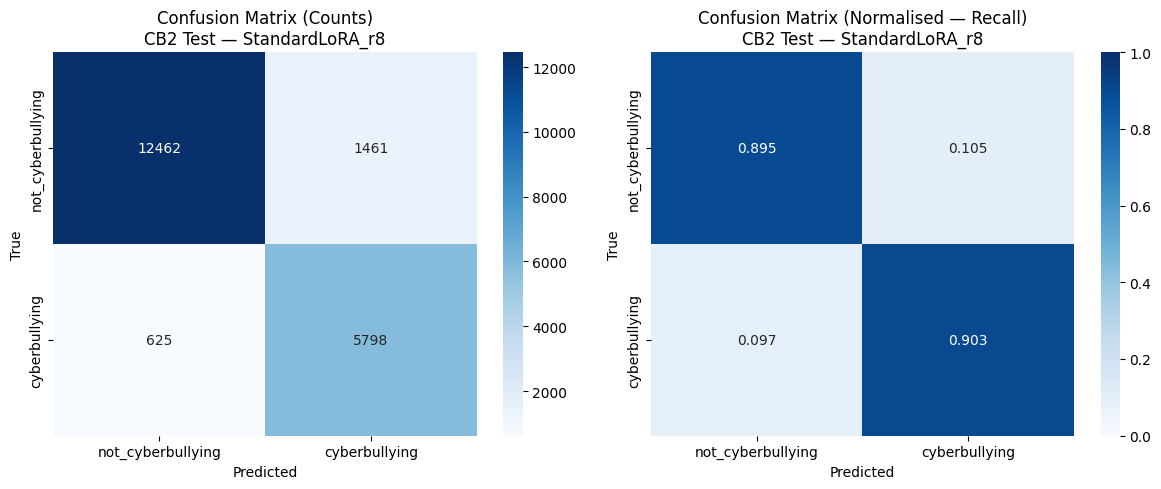


✓ Results saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r8/results_StandardLoRA_r8.csv

───────────────────────────────────────────────────────
  Rank sweep: r = 16
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 CB2 — STANDARD LoRA  |  StandardLoRA_r16
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W + AB  |  Task: Binary CB2

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Preparing datasets...


Map:   0%|          | 0/62261 [00:00<?, ? examples/s]

Map:   0%|          | 0/6918 [00:00<?, ? examples/s]

   Train: 62,261 | Val: 6,918 | Test: 20,346
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

   Trainable: 9,181,184 / 3,221,937,152  (0.285%)
   Class weights: not_cb=0.3484  |  cyberbullying=0.6516
[4] Training — 1 epoch...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.537857,0.402588,0.824227,0.815939,0.646712
200,0.397471,0.337985,0.864556,0.851420,0.702911
300,0.347677,0.291464,0.868459,0.860986,0.731754
400,0.350550,0.280776,0.875976,0.867497,0.739972
500,0.269454,0.313030,0.865568,0.858673,0.730234
600,0.414536,0.283978,0.883492,0.874870,0.753068
700,0.363161,0.336671,0.879879,0.863272,0.731049
800,0.342717,0.345397,0.878867,0.862041,0.728730
900,0.284993,0.269620,0.881902,0.873418,0.750760
1000,0.297407,0.274327,0.878867,0.870726,0.746851


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training time: 12882s  (3.58 hrs)

[5] Computing effective rank...
   avg_effective_rank(Wf) = 2030.79
   avg_effective_rank(ΔW) = 16.00  (≤ r=16)

[6] Generating stability report...
   loss_cv_overall     : 0.3066462003817745
   loss_std_overall    : 0.09013044498316743
   val_f1_std          : 0.014717523189716638
   stability_score     : 0.160682
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r16/stability_curves.png


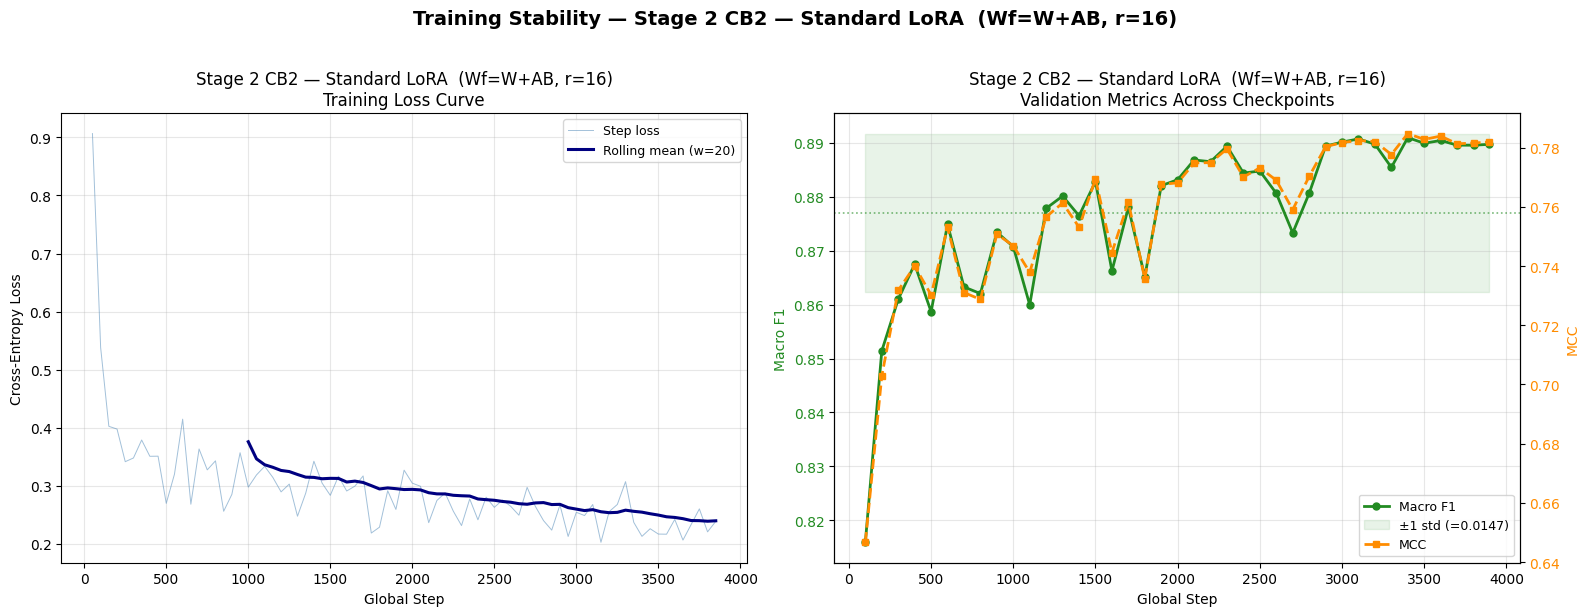

[7] Running inference on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB2 Test — StandardLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9007
  Macro F1          : 0.8884  ← PRIMARY METRIC
  Weighted F1       : 0.9020
  Balanced Accuracy : 0.9010
  MCC               : 0.7799  ← SECONDARY METRIC
  AUC-ROC           : 0.9646  ← SECONDARY METRIC
  F1 cyberbullying  : 0.8515  (minority class — label=1)
  F1 not_cb         : 0.9254  (majority class — label=0)

  Classification Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9521    0.9002    0.9254     13923
    cyberbullying     0.8065    0.9018    0.8515      6423

         accuracy                         0.9007     20346
        macro avg     0.8793    0.9010    0.8884     20346
     weighted avg     0.9061    0.9007    0.9020     20346



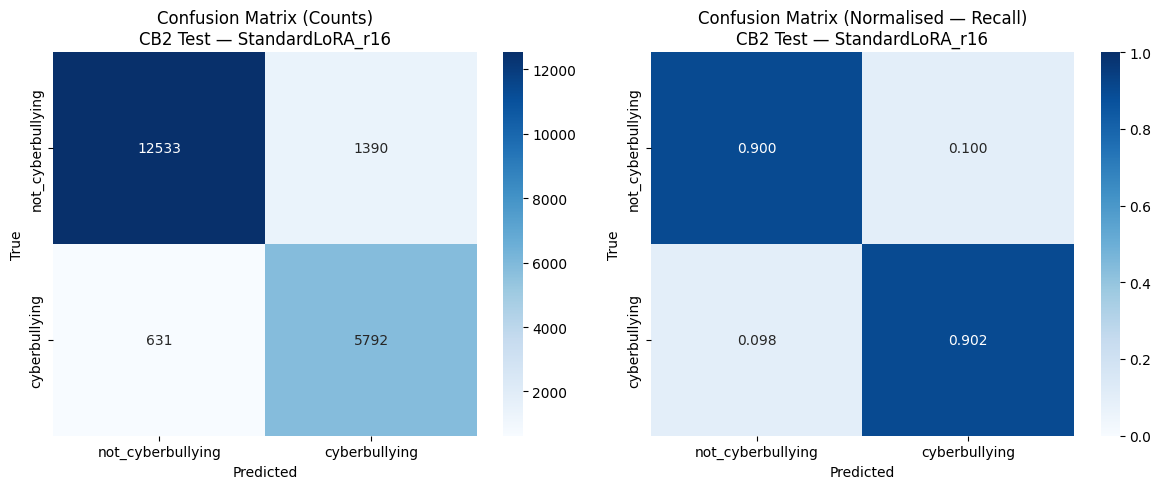


✓ Results saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r16/results_StandardLoRA_r16.csv

───────────────────────────────────────────────────────
  Rank sweep: r = 32
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 CB2 — STANDARD LoRA  |  StandardLoRA_r32
  Model   : meta-llama/Llama-3.2-3B-Instruct
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W + AB  |  Task: Binary CB2

[1] Loading tokenizer...
   Vocab size: 128,000
[2] Preparing datasets...


Map:   0%|          | 0/62261 [00:00<?, ? examples/s]

Map:   0%|          | 0/6918 [00:00<?, ? examples/s]

   Train: 62,261 | Val: 6,918 | Test: 20,346
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

   Trainable: 18,356,224 / 3,231,112,192  (0.568%)
   Class weights: not_cb=0.3484  |  cyberbullying=0.6516
[4] Training — 1 epoch...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
100,0.499195,0.432362,0.846777,0.829363,0.659253
200,0.414422,0.359643,0.860653,0.844495,0.689742
300,0.340682,0.287117,0.878144,0.868965,0.740897
400,0.346223,0.287108,0.868025,0.859931,0.727488
500,0.297768,0.343508,0.852269,0.846276,0.713193
600,0.405470,0.309712,0.870338,0.862865,0.735114
700,0.343268,0.347558,0.879300,0.862232,0.729710
800,0.314043,0.307968,0.883926,0.872354,0.744717
900,0.314072,0.277436,0.882191,0.873849,0.751930
1000,0.319805,0.279391,0.878433,0.869887,0.744141


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training time: 12879s  (3.58 hrs)

[5] Computing effective rank...
   avg_effective_rank(Wf) = 2030.73
   avg_effective_rank(ΔW) = 32.00  (≤ r=32)

[6] Generating stability report...
   loss_cv_overall     : 0.2921064771670947
   loss_std_overall    : 0.08602535939251996
   val_f1_std          : 0.019871910702585805
   stability_score     : 0.155989
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r32/stability_curves.png


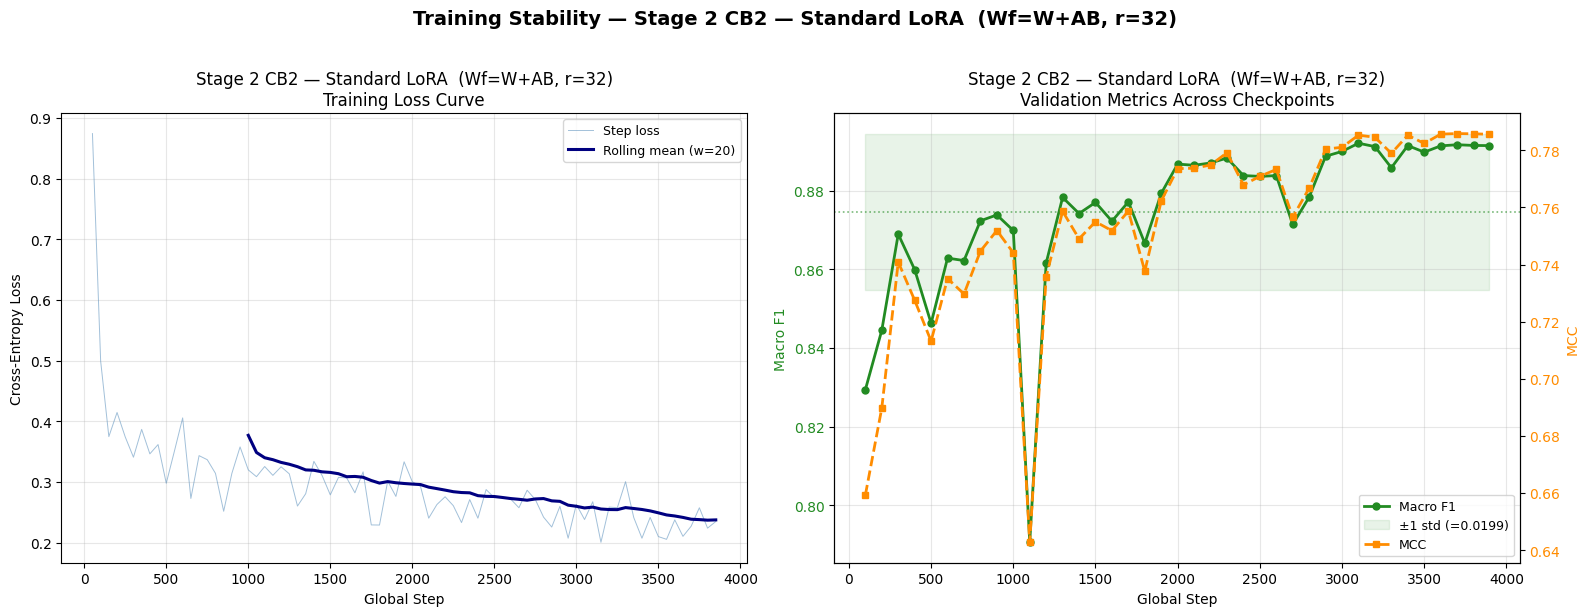

[7] Running inference on held-out test set (25%)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB2 Test — StandardLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9018
  Macro F1          : 0.8898  ← PRIMARY METRIC
  Weighted F1       : 0.9032
  Balanced Accuracy : 0.9031
  MCC               : 0.7831  ← SECONDARY METRIC
  AUC-ROC           : 0.9654  ← SECONDARY METRIC
  F1 cyberbullying  : 0.8536  (minority class — label=1)
  F1 not_cb         : 0.9261  (majority class — label=0)

  Classification Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9543    0.8996    0.9261     13923
    cyberbullying     0.8064    0.9066    0.8536      6423

         accuracy                         0.9018     20346
        macro avg     0.8803    0.9031    0.8898     20346
     weighted avg     0.9076    0.9018    0.9032     20346



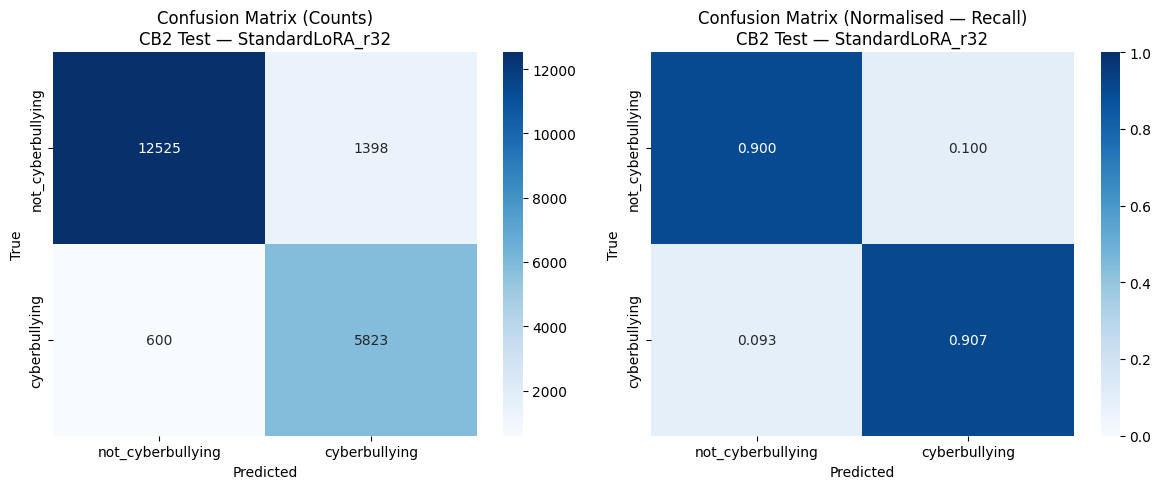


✓ Results saved → /content/drive/MyDrive/Results/CB2_StandardLoRA_Llama3B/StandardLoRA_r32/results_StandardLoRA_r32.csv

══════════════════════════════════════════════════════════════════════
  RANK SWEEP COMPLETE — Total Compute Summary
══════════════════════════════════════════════════════════════════════
  r=4   F1=0.8835  AUC=0.9627  MCC=0.7709  Time=12946s (3.60 hrs)
  r=8   F1=0.8852  AUC=0.9640  MCC=0.7740  Time=12876s (3.58 hrs)
  r=16  F1=0.8884  AUC=0.9646  MCC=0.7799  Time=12882s (3.58 hrs)
  r=32  F1=0.8898  AUC=0.9654  MCC=0.7831  Time=12879s (3.58 hrs)
──────────────────────────────────────────────────────────────────────
  Total training time  : 51582s  (14.33 hrs)
  Total wall-clock time: 53858s  (14.96 hrs)
  Overhead (load+eval) : 2276s
══════════════════════════════════════════════════════════════════════

RANK SWEEP RESULTS — Stage 2 CB2 Standard LoRA
Model: meta-llama/Llama-3.2-3B-Instruct
 Rank (r)  Trainable Params  Macro F1    MCC  AUC-ROC  F1 cyberbullying  Ef

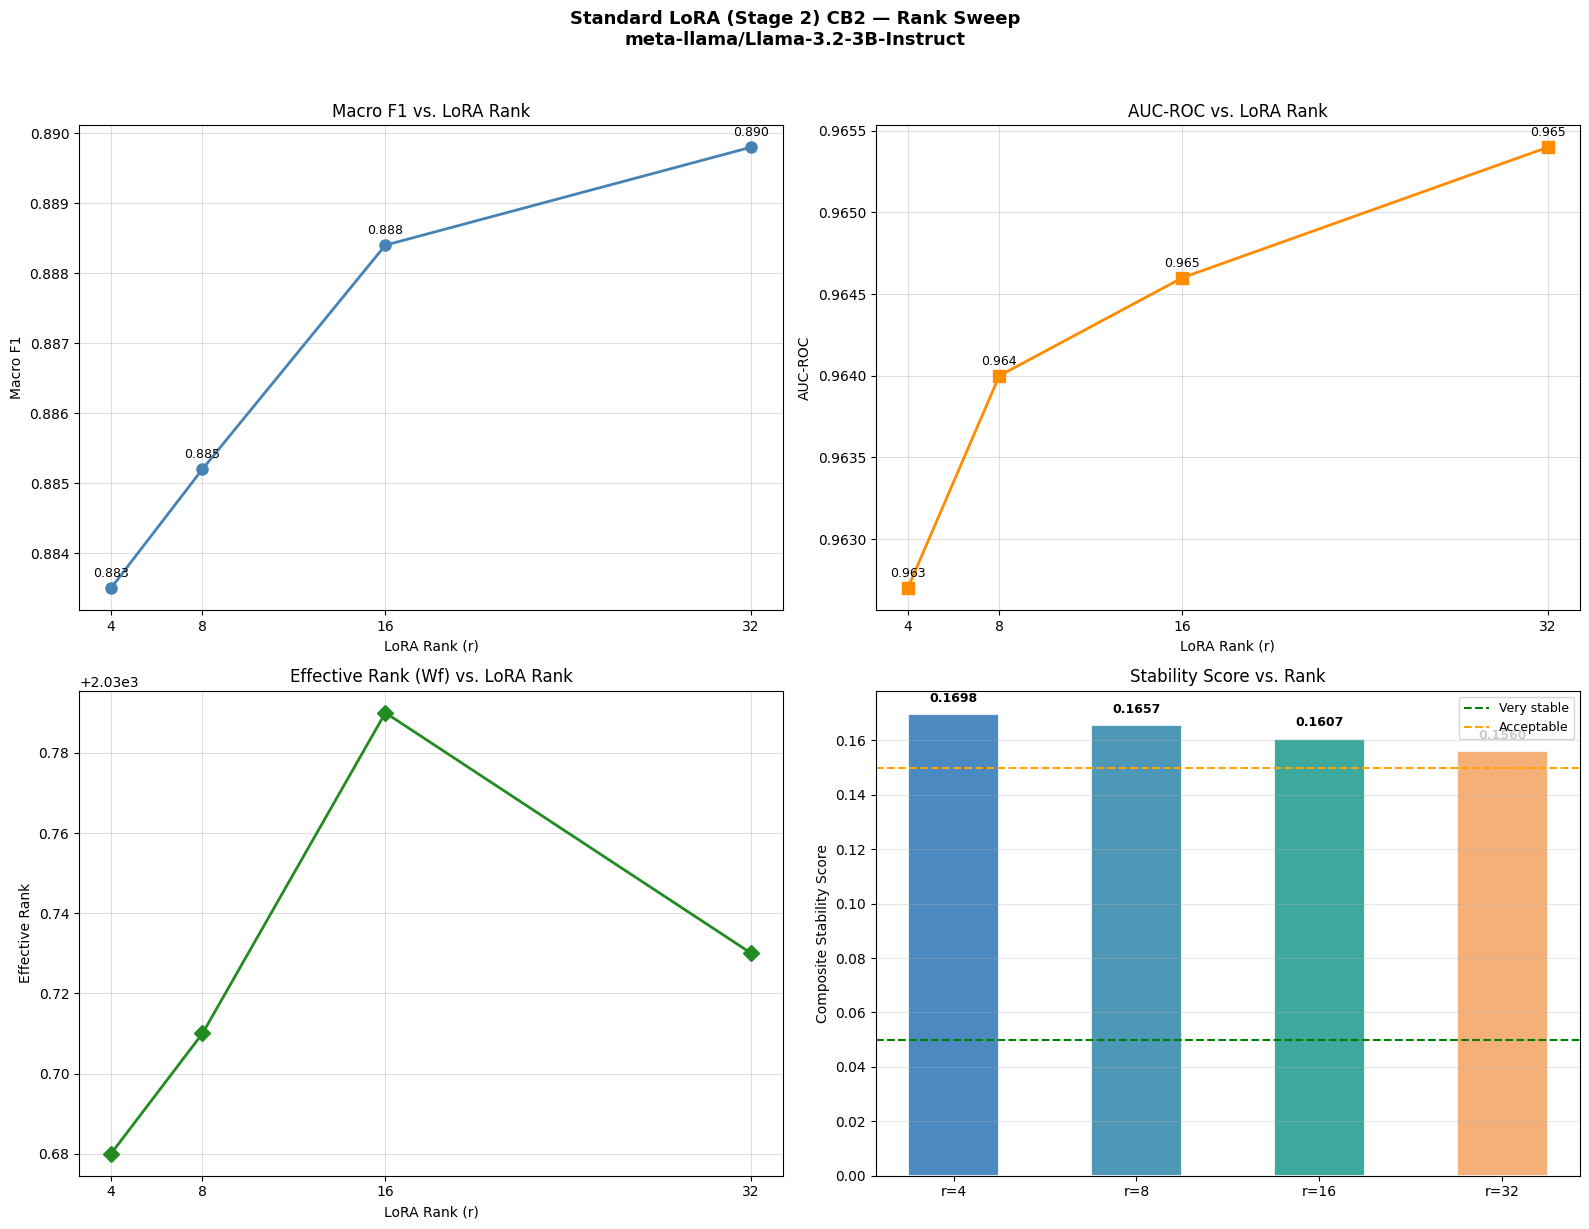

✓ Rank sweep plots saved.


In [ ]:
all_rank_results = []
sweep_start_time = time.time()

for r in RANK_SWEEP:
    print(f'\n{"─"*55}')
    print(f'  Rank sweep: r = {r}')
    print(f'{"─"*55}')
    res = run_standard_lora(
        train_df=train_df, val_df=val_df, test_df=test_df,
        lora_rank=r, run_label=f'StandardLoRA_r{r}')
    all_rank_results.append(res)

# ── Total compute time ────────────────────────────────────────────────────
sweep_end_time   = time.time()
total_runtime_s  = sweep_end_time - sweep_start_time
per_run_times    = [r.get('train_runtime_s', 0) for r in all_rank_results]
total_training_s = sum(per_run_times)

print('\n' + '═'*70)
print('  RANK SWEEP COMPLETE — Total Compute Summary')
print('═'*70)
for res, t in zip(all_rank_results, per_run_times):
    print(f"  r={res['lora_rank']:<2}  F1={res['macro_f1']:.4f}  "
          f"AUC={res['auc_roc']:.4f}  MCC={res['mcc']:.4f}  "
          f"Time={t:.0f}s ({t/3600:.2f} hrs)")
print(f"{'─'*70}")
print(f"  Total training time  : {total_training_s:.0f}s  ({total_training_s/3600:.2f} hrs)")
print(f"  Total wall-clock time: {total_runtime_s:.0f}s  ({total_runtime_s/3600:.2f} hrs)")
print(f"  Overhead (load+eval) : {(total_runtime_s - total_training_s):.0f}s")
print('═'*70)

summary_df = pd.DataFrame([{
    'Rank (r)':          res['lora_rank'],
    'Trainable Params':  res['trainable_params'],
    'Macro F1':          round(res['macro_f1'],        4),
    'MCC':               round(res['mcc'],              4),
    'AUC-ROC':           round(res['auc_roc'],          4),
    'F1 cyberbullying':  round(res['f1_cyberbullying'], 4),
    'Eff. Rank (Wf)':    round(res['avg_eff_rank_Wf'],  2),
    'Stability Score':   round(res['stability_score'],  6),
    'Train Time (s)':    round(res.get('train_runtime_s', 0), 0),
} for res in all_rank_results])

print('\nRANK SWEEP RESULTS — Stage 2 CB2 Standard LoRA')
print('Model: meta-llama/Llama-3.2-3B-Instruct')
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'rank_sweep_summary.csv'), index=False)
print(f'\n✓ Summary saved.')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].plot(summary_df['Rank (r)'], summary_df['Macro F1'],
               'o-', color='steelblue', linewidth=2, markersize=8)
for _, row in summary_df.iterrows():
    axes[0,0].annotate(f'{row["Macro F1"]:.3f}', (row['Rank (r)'], row['Macro F1']),
                       textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
axes[0,0].set_title('Macro F1 vs. LoRA Rank', fontsize=12)
axes[0,0].set_xlabel('LoRA Rank (r)'); axes[0,0].set_ylabel('Macro F1')
axes[0,0].set_xticks(RANK_SWEEP); axes[0,0].grid(True, alpha=0.4)

axes[0,1].plot(summary_df['Rank (r)'], summary_df['AUC-ROC'],
               's-', color='darkorange', linewidth=2, markersize=8)
for _, row in summary_df.iterrows():
    axes[0,1].annotate(f'{row["AUC-ROC"]:.3f}', (row['Rank (r)'], row['AUC-ROC']),
                       textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
axes[0,1].set_title('AUC-ROC vs. LoRA Rank', fontsize=12)
axes[0,1].set_xlabel('LoRA Rank (r)'); axes[0,1].set_ylabel('AUC-ROC')
axes[0,1].set_xticks(RANK_SWEEP); axes[0,1].grid(True, alpha=0.4)

axes[1,0].plot(summary_df['Rank (r)'], summary_df['Eff. Rank (Wf)'],
               'D-', color='forestgreen', linewidth=2, markersize=8)
axes[1,0].set_title('Effective Rank (Wf) vs. LoRA Rank', fontsize=12)
axes[1,0].set_xlabel('LoRA Rank (r)'); axes[1,0].set_ylabel('Effective Rank')
axes[1,0].set_xticks(RANK_SWEEP); axes[1,0].grid(True, alpha=0.4)

axes[1,1].bar(range(len(RANK_SWEEP)), summary_df['Stability Score'],
              color=['#2E75B6','#2E86AB','#1B998B','#F4A261'],
              alpha=0.85, edgecolor='white', linewidth=1.5, width=0.5)
for i, (_, row) in enumerate(summary_df.iterrows()):
    axes[1,1].text(i, row['Stability Score']+max(summary_df['Stability Score'])*0.02,
                   f'{row["Stability Score"]:.4f}', ha='center', va='bottom',
                   fontsize=9, fontweight='bold')
axes[1,1].axhline(0.05, color='green',  linestyle='--', linewidth=1.5, label='Very stable')
axes[1,1].axhline(0.15, color='orange', linestyle='--', linewidth=1.5, label='Acceptable')
axes[1,1].set_xticks(range(len(RANK_SWEEP)))
axes[1,1].set_xticklabels([f'r={r}' for r in RANK_SWEEP], fontsize=10)
axes[1,1].set_title('Stability Score vs. Rank', fontsize=12)
axes[1,1].set_ylabel('Composite Stability Score')
axes[1,1].legend(fontsize=9); axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Standard LoRA (Stage 2) CB2 — Rank Sweep\nmeta-llama/Llama-3.2-3B-Instruct',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rank_sweep_plots.png'), dpi=150, bbox_inches='tight')
plt.show(); print('✓ Rank sweep plots saved.')

---
## Step 14: Final Summary

In [ ]:
print('\n' + '═'*70)
print('  STAGE 2 CB2 COMPLETE — STANDARD (ADDITIVE) LoRA')
print('  Formula  : Wf = W + AB')
print('  Model    : meta-llama/Llama-3.2-3B-Instruct')
print('  Dataset  : CB2 — Binary Cyberbullying  (8.6:1 Imbalanced)')
print('  Split    : 75/25 stratified (protocol-compliant)')
print('═'*70)
print('\n── PRIMARY RESULTS (r=16) ──')
print(f'  Macro F1           : {results_r16["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC                : {results_r16["mcc"]:.4f}')
print(f'  AUC-ROC            : {results_r16["auc_roc"]:.4f}')
print(f'  F1 cyberbullying   : {results_r16["f1_cyberbullying"]:.4f}   (minority class)')
print(f'  Accuracy           : {results_r16["accuracy"]:.4f}')
print(f'  Trainable params   : {results_r16["trainable_params"]:,}')
print(f'  Eff. rank (Wf)     : {results_r16["avg_eff_rank_Wf"]:.2f}')
runtime_r16 = results_r16.get("train_runtime_s", 0)
print(f'  Training time      : {runtime_r16:.0f}s  ({runtime_r16/3600:.2f} hrs)')
print('\n── CB2 STAGE 1 TARGETS ──')
print('  DeBERTa ZS : F1=0.5957  MCC=0.2153            ← TRUE CEILING')
print('  Phi-4 FS   : F1=0.5170  MCC=0.2030  AUC=0.664')
print('  DeBERTa FS : F1=0.0941  MCC=-0.033            ← WORST')
print('\n── RANK SWEEP COMPUTE ──')
try:
    print(f'  Total training time  : {total_training_s:.0f}s  ({total_training_s/3600:.2f} hrs)')
    print(f'  Total wall-clock time: {total_runtime_s:.0f}s  ({total_runtime_s/3600:.2f} hrs)')
except NameError:
    print('  (Run Step 13 for total compute summary)')


══════════════════════════════════════════════════════════════════════
  STAGE 2 CB2 COMPLETE — STANDARD (ADDITIVE) LoRA
  Formula  : Wf = W + AB
  Model    : meta-llama/Llama-3.2-3B-Instruct
  Dataset  : CB2 — Binary Cyberbullying  (8.6:1 Imbalanced)
  Split    : 75/25 stratified (protocol-compliant)
══════════════════════════════════════════════════════════════════════

── PRIMARY RESULTS (r=16) ──
  Macro F1           : 0.8885   ← PRIMARY METRIC
  MCC                : 0.7800
  AUC-ROC            : 0.9650
  F1 cyberbullying   : 0.8515   (minority class)
  Accuracy           : 0.9008
  Trainable params   : 9,181,184
  Eff. rank (Wf)     : 2030.70
  Training time      : 12874s  (3.58 hrs)

── CB2 STAGE 1 TARGETS ──
  DeBERTa ZS : F1=0.5957  MCC=0.2153            ← TRUE CEILING
  Phi-4 FS   : F1=0.5170  MCC=0.2030  AUC=0.664
  DeBERTa FS : F1=0.0941  MCC=-0.033            ← WORST

── RANK SWEEP COMPUTE ──
  Total training time  : 51582s  (14.33 hrs)
  Total wall-clock time: 53858s  (14